# 08 — What can the images predict on their own?

Ground truth comes from the transcriptome (cell-type annotation, niches); inputs are **image features only**
(intensities, distributions, texture, morphology, edge distance; no transcript counts). Gradient-boosted trees,
5-fold cross-validation **grouped by animal** (test animals never seen in training), 18S-segmented cells.

1. Cell type (L1) — overall, per class, confusions.
2. Which stain carries identity — single-channel and morphology-only models, everything-but-18S (18S drew the masks),
   and cell + **image-only neighbourhood** (mean image features of the 15 nearest cells).
3. Subtypes within a type (L2).
4. Anatomy and lesion state from images vs a transcriptome-composition baseline (cell types of the 15 nearest cells).

> **Interim version** — sections 1–4 only (all models cached). Sections 5 (animal metadata) and 6 (lesion maps) are
> still running on the analysis Mac; the full notebook will replace this file.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold

from beyondboundaries import data, plotting

plotting.style()
SRC = "notebooks/08_image_only_prediction.ipynb"
OUT = ROOT / "results" / "08_image_only_prediction"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / "data" / "pred08"
CACHE.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
rng = np.random.default_rng(0)

fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].copy()
for ch in CH:
    fa[f"{ch}_rim_over_ring"] = (fa[f"{ch}_rim_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"]) / \
                                (fa[f"{ch}_ring_mean"] + fa[f"{ch}_bg_local"] / fa[f"{ch}_scale"])

CELL = []
for ch in CH:
    CELL += [f"{ch}_{c}_{s}" for c in ("nuc", "cyto", "rim", "ring", "terr") for s in ("mean", "p90")]
    CELL += [f"{ch}_radial_b{k}" for k in range(5)]
    CELL += [f"{ch}_polarity_shape", f"{ch}_polarity_nuc", f"{ch}_rim_over_ring"]
    CELL += [f"{ch}_glcm_{k}" for k in ("contrast", "homogeneity", "asm", "entropy", "correlation")]
MORPH = [c for c in fa.columns if c.startswith("morph_") and c != "morph_cell_orientation"] + ["nuc_offset"]
CELL += MORPH + ["edge_um"]

# image-only neighbourhood: mean of a compact image feature set over the 15 nearest cells (same section, self excluded)
NB_BASE = [f"{ch}_{c}_mean" for ch in CH for c in ("nuc", "cyto", "terr")] + \
          [f"{ch}_glcm_{k}" for ch in CH for k in ("contrast", "correlation")] + \
          ["morph_cell_area_um2", "morph_nuc_cell_ratio", "morph_cell_eccentricity"]
K = 15
nb = np.full((len(fa), len(NB_BASE)), np.nan, np.float32)
vals = fa[NB_BASE].values.astype(np.float32)
for _, idx in fa.groupby("section_id", observed=True).indices.items():
    xy = fa[["x_centroid", "y_centroid"]].values[idx]
    _, nn = cKDTree(xy).query(xy, k=min(K + 1, len(idx)))
    nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)
NBH = [f"nbhd_{c}" for c in NB_BASE]
fa[NBH] = nb
print(len(CELL), "cell image features;", len(NBH), "neighbourhood image features")


def cv_predict(df, y, feats, key, groups="sample_name", max_per_class=6000, n_folds=5):
    """Grouped-CV predictions (cached). Balanced subsample per class to keep runtime bounded."""
    cache = CACHE / f"{key}.parquet"
    if cache.exists():
        return pd.read_parquet(cache)
    y = pd.Series(y, index=df.index).astype(str)
    keep = np.concatenate([rng.choice(g.index.values, min(len(g), max_per_class), replace=False)
                           for _, g in y.groupby(y)])
    d, yy = df.loc[keep], y.loc[keep]
    X = d[feats].values.astype(np.float32)
    pred = pd.Series(index=d.index, dtype=object)
    classes = np.sort(yy.unique())
    proba = pd.DataFrame(0.0, index=d.index, columns=classes)
    for tr, te in GroupKFold(n_folds).split(X, groups=d[groups].astype(str).values):
        m = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1, early_stopping=True, random_state=0,
                                           class_weight="balanced").fit(X[tr], yy.values[tr])
        pred.iloc[te] = m.predict(X[te])
        proba.iloc[te, :] = pd.DataFrame(m.predict_proba(X[te]), columns=m.classes_).reindex(columns=classes, fill_value=0).values
    out = pd.concat([pd.DataFrame({"true": yy, "pred": pred.astype(str)}), proba.add_prefix("p_")], axis=1)
    out.to_parquet(cache)
    return out


def scores(r):
    return pd.Series({"balanced acc.": balanced_accuracy_score(r.true, r.pred),
                      "macro F1": f1_score(r.true, r.pred, average="macro"),
                      "chance (balanced)": 1 / r.true.nunique(), "n": len(r)})

/tmp/ipykernel_72149/931679479.py:51: RuntimeWarning: Mean of empty slice
  nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)


/tmp/ipykernel_72149/931679479.py:51: RuntimeWarning: Mean of empty slice
  nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)


/tmp/ipykernel_72149/931679479.py:51: RuntimeWarning: Mean of empty slice
  nb[idx] = np.nanmean(vals[idx][nn[:, 1:]], axis=1)


106 cell image features; 23 neighbourhood image features


## 1. Cell type (L1) from images only

In [2]:
vc = fa.Anno_L1_curated.value_counts()
TYPES = [t for t in vc.index if vc[t] >= 500 and t not in ("Doublet", "T_B_doublet")]
ct = fa[fa.Anno_L1_curated.isin(TYPES)]
r_all = cv_predict(ct, ct.Anno_L1_curated, CELL + NBH, "L1_cell+nbhd")
r_cell = cv_predict(ct, ct.Anno_L1_curated, CELL, "L1_cell")
pd.DataFrame({"cell features": scores(r_cell), "cell + image neighbourhood": scores(r_all)}).T.round(3)

,balanced acc.,macro F1,chance (balanced),n
cell features,0.444,0.433,0.071,75601.0
cell + image neighbourhood,0.464,0.455,0.071,75601.0


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/L1_confusion.png')

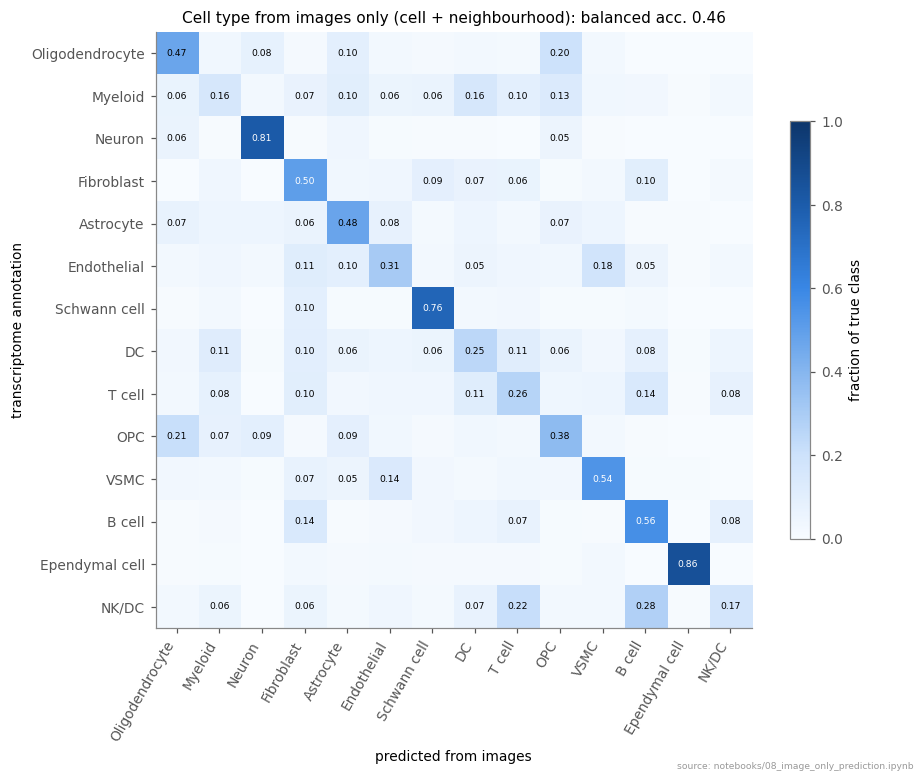

In [3]:
order = [t for t in TYPES]
cm = confusion_matrix(r_all.true, r_all.pred, labels=order, normalize="true")
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cm, cmap=plotting.SEQ, vmin=0, vmax=1)
for i in range(len(order)):
    for j in range(len(order)):
        if cm[i, j] >= 0.05:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > 0.5 else "black")
ax.set_xticks(range(len(order)), order, rotation=60, ha="right"); ax.set_yticks(range(len(order)), order)
ax.set_xlabel("predicted from images"); ax.set_ylabel("transcriptome annotation")
fig.colorbar(im, ax=ax, label="fraction of true class", shrink=0.7)
ax.set_title(f"Cell type from images only (cell + neighbourhood): balanced acc. {scores(r_all)['balanced acc.']:.2f}")
fig.tight_layout()
plotting.save_fig(fig, "L1_confusion", OUT, SRC)

,cell features,cell + neighbourhood
Myeloid,0.139,0.156
NK/DC,0.174,0.172
DC,0.212,0.247
T cell,0.240,0.265
Endothelial,0.286,0.306
OPC,0.371,0.379
Oligodendrocyte,0.463,0.471
Astrocyte,0.462,0.475
Fibroblast,0.472,0.500
VSMC,0.499,0.543


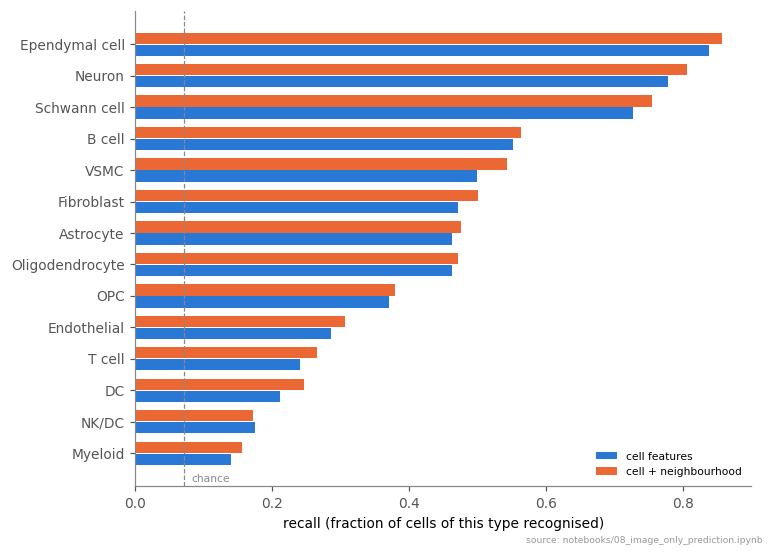

In [4]:
rec = pd.DataFrame({"cell features": pd.Series(np.diag(confusion_matrix(r_cell.true, r_cell.pred, labels=order, normalize="true")), index=order),
                    "cell + neighbourhood": pd.Series(np.diag(cm), index=order)})
rec = rec.sort_values("cell + neighbourhood")
fig, ax = plt.subplots(figsize=(7, 5))
y = np.arange(len(rec))
for k, c in enumerate(rec.columns):
    ax.barh(y + (k - 0.5) * 0.38, rec[c], height=0.36, color=plotting.CATEGORICAL[k], label=c)
ax.axvline(1 / len(order), color="#888888", lw=0.8, ls="--")
ax.text(1 / len(order) + 0.01, -0.9, "chance", fontsize=7, color="#888888")
ax.set_yticks(y, rec.index); ax.set_xlabel("recall (fraction of cells of this type recognised)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "L1_recall_per_type", OUT, SRC)
rec.round(3)

## 2. Which stain carries cell identity?
Same task, restricted feature sets (cell features only, no neighbourhood; ≤ 3,000 cells per class for the
restricted sets — the full-feature rows are the 6,000-per-class models from section 1).

,balanced acc.,macro F1,chance (balanced),n
morphology only,0.172,0.162,0.071,41046.0
DAPI only,0.239,0.226,0.071,41046.0
ATP1A1/CD45/E-Cad only,0.211,0.195,0.071,41046.0
18S rRNA only,0.274,0.252,0.071,41046.0
αSMA/Vimentin only,0.254,0.230,0.071,41046.0
"all channels, no morphology",0.399,0.387,0.071,41046.0
all except 18S,0.400,0.391,0.071,41046.0
all image (cell),0.444,0.433,0.071,75601.0
all image + neighbourhood,0.464,0.455,0.071,75601.0


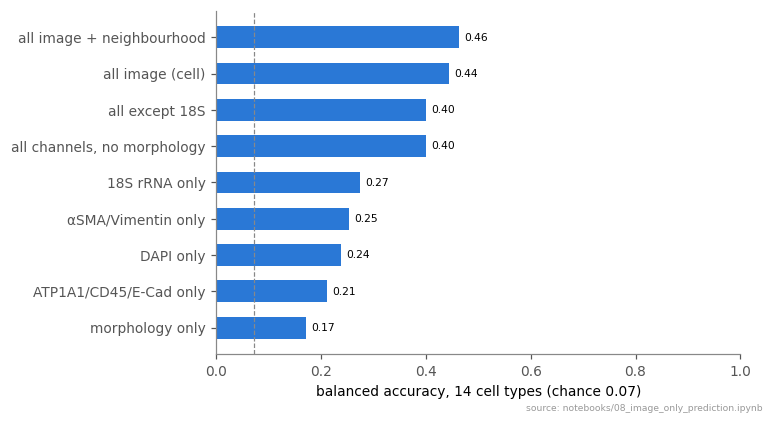

In [5]:
SETS = {"morphology only": MORPH,
        **{f"{plotting.CHANNEL_LABELS[ch]} only": [c for c in CELL if c.startswith(ch + "_")] for ch in CH},
        "all channels, no morphology": [c for c in CELL if c.split("_")[0] in CH],
        "all except 18S": [c for c in CELL if not c.startswith("r18s_")],
        "all image (cell)": CELL, "all image + neighbourhood": CELL + NBH}
# ablation models use ≤ 3,000 cells per class (relative comparison); the two full sets reuse the models above
abl = {}
for name, feats in SETS.items():
    if name == "all image (cell)":
        r = r_cell
    elif name == "all image + neighbourhood":
        r = r_all
    else:
        r = cv_predict(ct, ct.Anno_L1_curated, feats, "L1_" + name.replace(" ", "_").replace("/", "-"), max_per_class=3000)
    abl[name] = scores(r)
abl = pd.DataFrame(abl).T
abl.to_csv(OUT / "L1_feature_set_ablation.csv")
fig, ax = plt.subplots(figsize=(7, 3.8))
ab = abl.sort_values("balanced acc.")
ax.barh(ab.index, ab["balanced acc."], color=plotting.CATEGORICAL[0], height=0.6)
ax.axvline(1 / len(TYPES), color="#888888", lw=0.8, ls="--")
for i, v in enumerate(ab["balanced acc."]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=7)
ax.set_xlabel(f"balanced accuracy, {len(TYPES)} cell types (chance {1 / len(TYPES):.2f})"); ax.set_xlim(0, 1)
fig.tight_layout()
plotting.save_fig(fig, "L1_feature_set_ablation", OUT, SRC)
abl.round(3)

### Where are the images right and wrong? (one section)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/L1_map_correct_wrong.png')

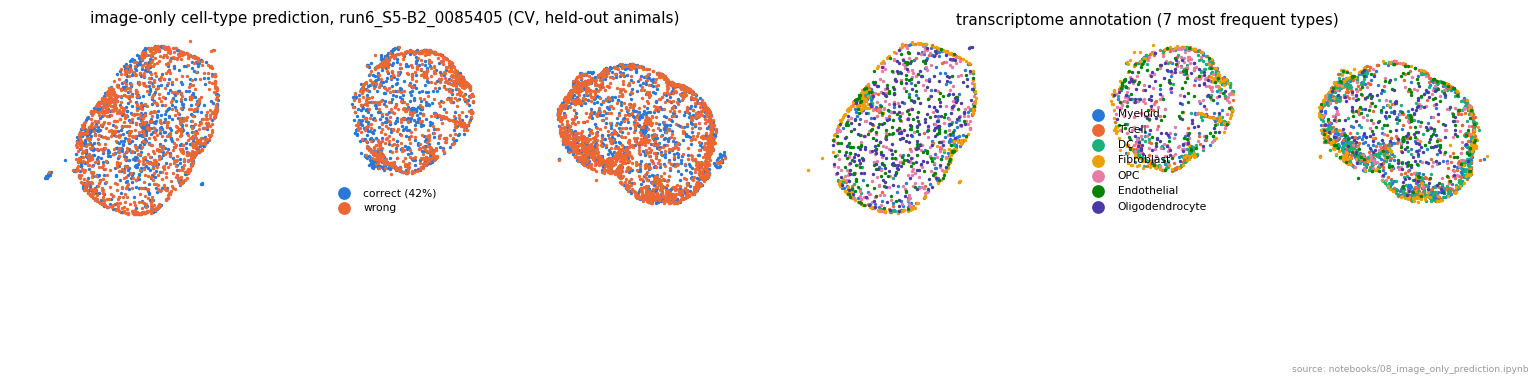

In [6]:
SEC = ct.section_id.value_counts().index[0]
full = cv_predict(ct, ct.Anno_L1_curated, CELL + NBH, "L1_cell+nbhd")  # subsample → plot cells that were predicted
d = ct.loc[ct.index.intersection(full.index)]
d = d[d.section_id == SEC].join(full)
ok = d.true == d.pred
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
axs[0].scatter(d.x_centroid[ok], -d.y_centroid[ok], s=1.5, color=plotting.CATEGORICAL[0], label=f"correct ({ok.mean():.0%})", rasterized=True)
axs[0].scatter(d.x_centroid[~ok], -d.y_centroid[~ok], s=1.5, color=plotting.CATEGORICAL[1], label="wrong", rasterized=True)
axs[0].set_title(f"image-only cell-type prediction, {SEC} (CV, held-out animals)"); axs[0].legend(markerscale=6, fontsize=7)
top = d.true.value_counts().index[:7]
for k, t_ in enumerate(top):
    m = d.true == t_
    axs[1].scatter(d.x_centroid[m], -d.y_centroid[m], s=1.5, color=plotting.CATEGORICAL[k], label=t_, rasterized=True)
axs[1].set_title("transcriptome annotation (7 most frequent types)"); axs[1].legend(markerscale=6, fontsize=7)
for a in axs:
    a.set_aspect("equal"); a.axis("off")
fig.tight_layout()
plotting.save_fig(fig, "L1_map_correct_wrong", OUT, SRC)

## 3. Subtypes within a type (L2), from images only

In [7]:
rows, sub_res = [], {}
for parent in ["Myeloid", "Astrocyte", "Oligodendrocyte", "Neuron", "Fibroblast", "T cell", "DC"]:
    d = fa[fa.Anno_L1_curated == parent]
    vc2 = d.Anno_L2.value_counts()
    keep = [c for c in vc2.index if vc2[c] >= 300 and "LowQuality" not in c and c not in ("Doublet", "ARTIFACT", "Mixed")]
    if len(keep) < 2:
        continue
    d = d[d.Anno_L2.isin(keep)]
    r = cv_predict(d, d.Anno_L2, CELL + NBH, f"L2_{parent.replace(' ', '_').replace('/', '-')}", max_per_class=5000)
    sub_res[parent] = r
    s = scores(r)
    per = pd.Series(np.diag(confusion_matrix(r.true, r.pred, labels=keep, normalize="true")), index=keep)
    rows.append(dict(parent=parent, subtypes=", ".join(f"{k} ({v:.2f})" for k, v in per.items()), **s))
l2 = pd.DataFrame(rows).set_index("parent")
l2.to_csv(OUT / "L2_within_type.csv")
l2[["balanced acc.", "chance (balanced)", "macro F1", "n", "subtypes"]].round(3)

,balanced acc.,chance (balanced),macro F1,n,subtypes
parent,,,,,
Myeloid,0.533,0.250,0.525,15911.0,"Microglia (0.72), MDM (0.53), CAM (0.61), Myel..."
Astrocyte,0.598,0.250,0.565,12761.0,"Reactive_AST (0.68), Homo_AST (0.60), Neurovas..."
Oligodendrocyte,0.468,0.250,0.467,16438.0,"MOL (0.65), DAO (0.48), NFOL (0.56), OPC/COP (..."
Neuron,0.640,0.333,0.637,12169.0,"Exc (0.57), Inh (0.63), Chol (0.72)"
Fibroblast,0.371,0.125,0.356,24271.0,"Fibroblast (0.25), Meningeal FBs (0.56), EAE -..."
T cell,0.447,0.333,0.419,6344.0,"CD4+ T Cell (0.74), CD8+ T Cell (0.54), T Cell..."
DC,0.661,0.500,0.644,5772.0,"GMP-DC (0.87), CLP-DC (0.45)"


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/L2_within_type.png')

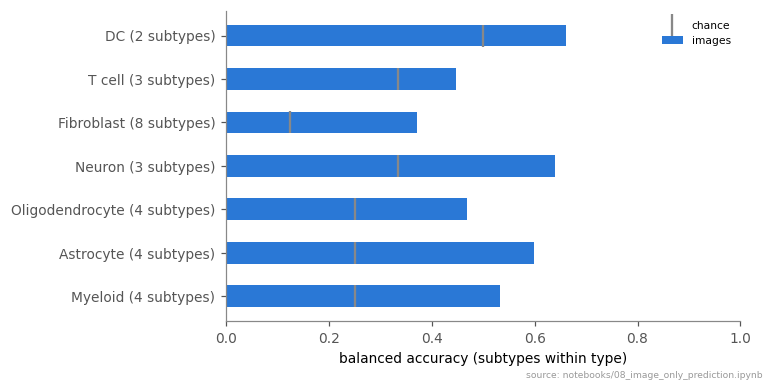

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
y = np.arange(len(l2))
ax.barh(y, l2["balanced acc."], color=plotting.CATEGORICAL[0], height=0.5, label="images")
ax.scatter(l2["chance (balanced)"], y, color="#888888", marker="|", s=200, label="chance", zorder=3)
ax.set_yticks(y, [f"{p} ({len(s.split(','))} subtypes)" for p, s in zip(l2.index, l2.subtypes)])
ax.set_xlabel("balanced accuracy (subtypes within type)"); ax.set_xlim(0, 1); ax.legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "L2_within_type", OUT, SRC)

Microglia vs monocyte-derived macrophages is the immunologically most relevant split — confusion:

In [9]:
if "Myeloid" in sub_res:
    r = sub_res["Myeloid"]
    labs = sorted(r.true.unique())
    print(pd.DataFrame(confusion_matrix(r.true, r.pred, labels=labs, normalize="true"), index=labs, columns=labs).round(2))

            CAM   MDM  Microglia  Myeloid
CAM        0.61  0.17       0.13     0.09
MDM        0.26  0.53       0.15     0.06
Microglia  0.13  0.08       0.72     0.07
Myeloid    0.35  0.17       0.20     0.27


## 4. Anatomy and lesion state from images
Same model on all cell types together. Baseline: the *transcriptome-defined* cell-type composition of the 15 nearest
cells (what the niche annotation itself is built from).

In [10]:
comp = pd.get_dummies(fa.Anno_L1_curated.astype(str)).astype(np.float32)
compn = np.zeros(comp.shape, np.float32)
cv_ = comp.values
for _, idx in fa.groupby("section_id", observed=True).indices.items():
    xy = fa[["x_centroid", "y_centroid"]].values[idx]
    _, nn = cKDTree(xy).query(xy, k=min(K + 1, len(idx)))
    compn[idx] = cv_[idx][nn[:, 1:]].mean(1)
COMP = [f"comp_{c}" for c in comp.columns]
fa[COMP] = compn
TASKS = {"anatomical region": "Global_anatomical_region", "lesion state": "Curated_niche_state"}
rows, maps = [], {}
for name, col in TASKS.items():
    vc3 = fa[col].value_counts()
    keep = [c for c in vc3.index if vc3[c] >= 2000]
    d = fa[fa[col].isin(keep)]
    for fs_name, feats in (("images (cell + neighbourhood)", CELL + NBH), ("transcriptome cell-type composition", COMP),
                           ("both", CELL + NBH + COMP)):
        r = cv_predict(d, d[col], feats, f"{col}_{fs_name.split()[0]}", max_per_class=8000)
        rows.append(dict(task=name, inputs=fs_name, classes=len(keep), **scores(r)))
        maps[(name, fs_name)] = r
nt = pd.DataFrame(rows)
nt.to_csv(OUT / "anatomy_lesion_prediction.csv", index=False)
nt.round(3)

,task,inputs,classes,balanced acc.,macro F1,chance (balanced),n
0,anatomical region,images (cell + neighbourhood),10,0.625,0.624,0.100,76562.0
1,anatomical region,transcriptome cell-type composition,10,0.683,0.679,0.100,76562.0
2,anatomical region,both,10,0.730,0.729,0.100,76562.0
3,lesion state,images (cell + neighbourhood),7,0.535,0.533,0.143,43759.0
4,lesion state,transcriptome cell-type composition,7,0.648,0.617,0.143,43759.0
5,lesion state,both,7,0.665,0.659,0.143,43759.0


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/08_image_only_prediction/anatomy_lesion_prediction.png')

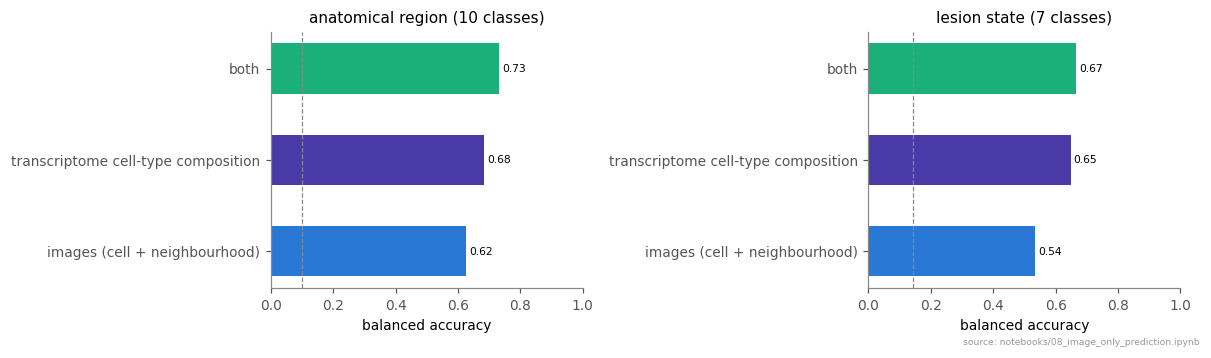

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2), sharex=True)
for ax, (name, g) in zip(axs, nt.groupby("task", sort=False)):
    ax.barh(g.inputs, g["balanced acc."], color=[plotting.CATEGORICAL[k] for k in (0, 6, 2)], height=0.55)
    ax.axvline(g["chance (balanced)"].iloc[0], color="#888888", lw=0.8, ls="--")
    for i, v in enumerate(g["balanced acc."]):
        ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=7)
    ax.set_title(f"{name} ({g.classes.iloc[0]} classes)"); ax.set_xlim(0, 1)
axs[0].set_xlabel("balanced accuracy"); axs[1].set_xlabel("balanced accuracy")
fig.tight_layout()
plotting.save_fig(fig, "anatomy_lesion_prediction", OUT, SRC)

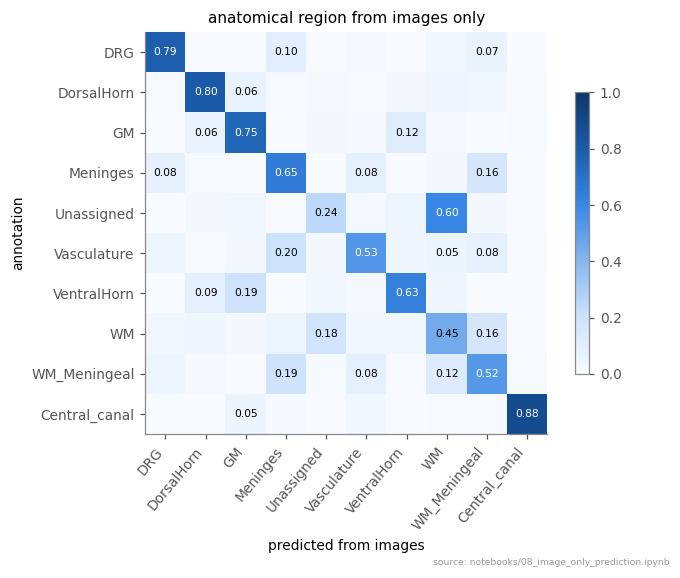

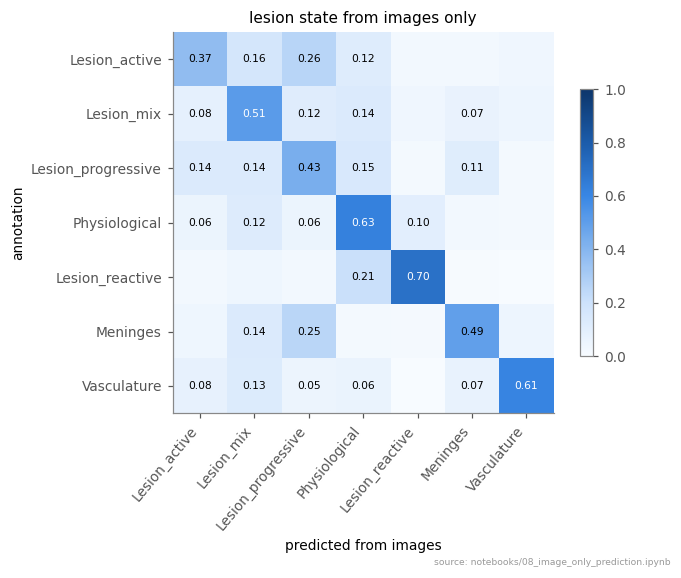

In [12]:
for name in TASKS:
    r = maps[(name, "images (cell + neighbourhood)")]
    labs = list(r.true.value_counts().index)
    cm = confusion_matrix(r.true, r.pred, labels=labs, normalize="true")
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    im = ax.imshow(cm, cmap=plotting.SEQ, vmin=0, vmax=1)
    for i in range(len(labs)):
        for j in range(len(labs)):
            if cm[i, j] >= 0.05:
                ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if cm[i, j] > 0.5 else "black")
    ax.set_xticks(range(len(labs)), labs, rotation=50, ha="right"); ax.set_yticks(range(len(labs)), labs)
    ax.set_xlabel("predicted from images"); ax.set_ylabel("annotation")
    ax.set_title(f"{name} from images only")
    fig.colorbar(im, ax=ax, shrink=0.7)
    fig.tight_layout()
    plotting.save_fig(fig, f"confusion_{name.replace(' ', '_')}", OUT, SRC)